How to get & save samples from saved chain (.h5 file)

In [215]:
import emcee
from escripts import edata
from escripts import eMCMC
import importlib
from escripts import eplots
import dataframe_image as dfi

In [3]:
file_name = '/Users/eb35267/Desktop/code/figures/replicate_muñoz23_hst/samples.h5'

In [198]:
# Get data
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt']
data_labels = ['Bouwens+21']
sorted_data = edata.get_sorted(file_names, data_labels)

# Initialize parameters
params = params = eMCMC.build_param_data({'dsigdlogM': {'fit':False, 'value':0}})

# Add Muñoz+23 fits for comparison
munoz_fit_vary_eps = [0.61, -0.01, -1.91, 0.08, 12.03, 0.03, '-', '-', 0.65, -0.03]
munoz_fit_vary_sig = [0.74, 0.03, -1.76, -0.02, 11.84, -0.02, -1.08, -0.07, '-', '-']

run_name = 'replicate_muñoz23_hst'
folder = f'/Users/eb35267/Desktop/code/figures/{run_name}'

In [ ]:
importlib.reload(eMCMC)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

In [188]:
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [194]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

/Users/eb35267/Desktop/code/figures/replicate_muñoz23_hst/samples.h5
hi
/Users/eb35267/Desktop/code/figures/replicate_muñoz23_hst/samples.h5
/Users/eb35267/Desktop/code/figures/replicate_muñoz23_hst/samples.h5


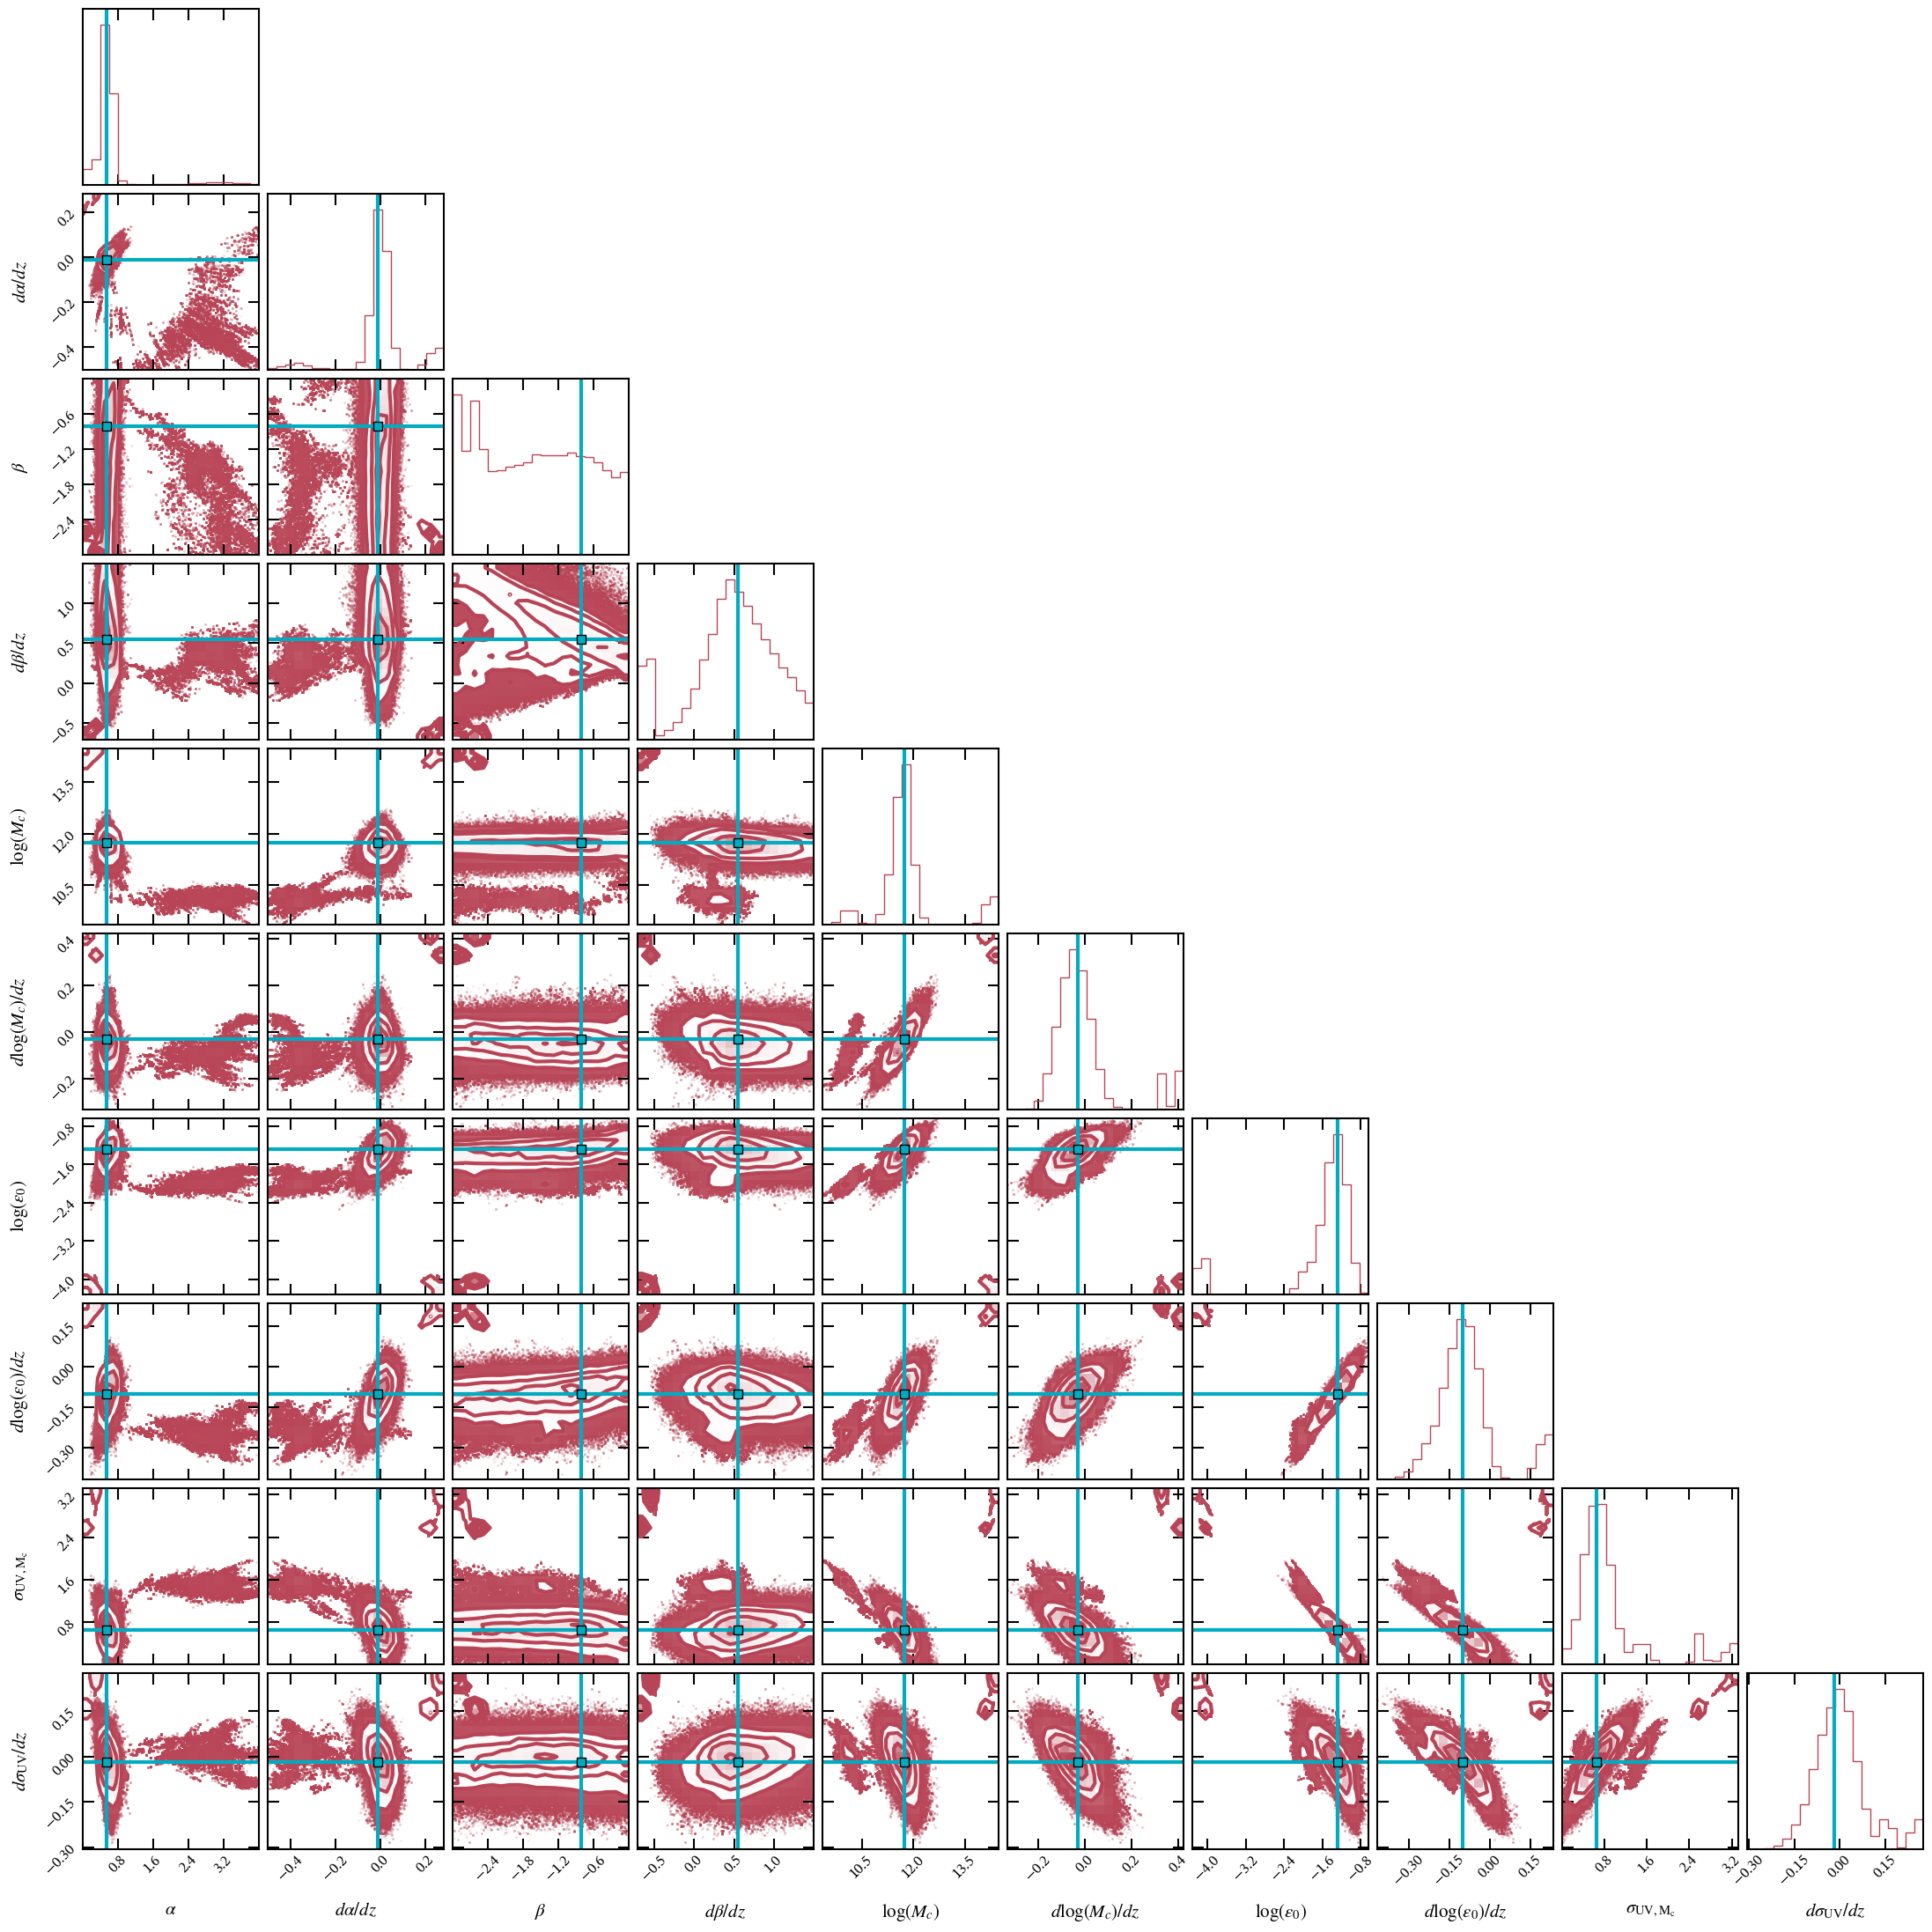

In [199]:
# Make & save figures
_, best_fit, bounds, param_labels = my_UVLF.get_fit(backend_file = file_name)

# Corner plot
corner = eplots.make_corner(my_UVLF, backend_file = file_name, true_vals = best_fit)
corner.savefig(f'{folder}/corner.png', bbox_inches = 'tight')

In [201]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

In [ ]:
import

/Users/eb35267/Desktop/code/figures/replicate_muñoz23_hst/samples.h5


/Users/eb35267/Desktop/code/home/escripts/eplots.py:211: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',
/Users/eb35267/Desktop/code/home/escripts/eplots.py:211: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',
/Users/eb35267/Desktop/code/home/escripts/eplots.py:211: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',
/Users/eb35267/Desktop/code/home/escripts/eplots.py:211: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',
/Users/eb35267/Desktop/code/home/escripts/eplots.py:211: Runt

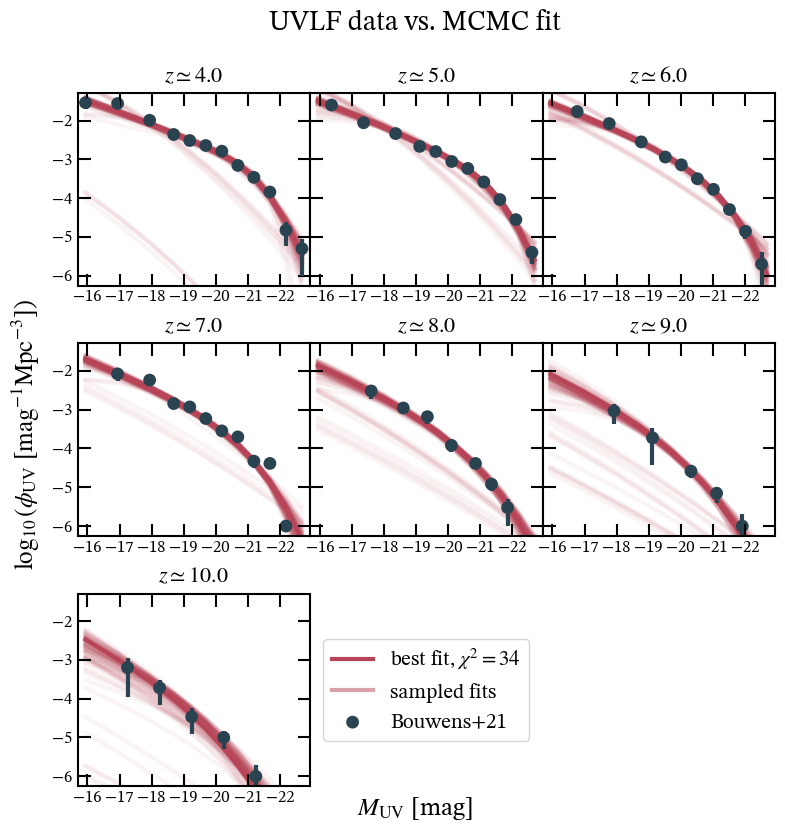

In [236]:
# UVLF plot
ev_fig = eplots.evolving_UVLF_fit(my_UVLF, file_name)
ev_fig.savefig(f'{folder}/evolving_UVLF.png', bbox_inches = 'tight')

In [211]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

In [216]:
# Parameter table
table = eplots.make_table([best_fit, munoz_fit_vary_eps, munoz_fit_vary_sig], param_labels, ['best fit', r'Muñoz+23 piecewise $\epsilon_0$', 
                                                                                             r'Muñoz+23 piecewise $\sigma_{\rm{UV}}$'], 
                          [bounds, None, None])
dfi.export(table, f'{folder}/table.png', table_conversion = 'matplotlib', use_mathjax = True, dpi = 200)

In [213]:
table

,best fit,Muñoz+23 piecewise $\epsilon_0$,Muñoz+23 piecewise $\sigma_{\rm{UV}}$
$\alpha$,$0.54^{+0.14}_{-0.11}$,0.61,0.74
$d\alpha/dz$,$-0.01^{+0.05}_{-0.03}$,-0.01,0.03
$\beta$,$-0.81^{+0.24}_{-1.83}$,-1.91,-1.76
$d\beta/dz$,$0.55^{+0.47}_{-0.52}$,0.08,-0.02
$\log(M_c)$,$11.74^{+0.28}_{-0.39}$,12.03,11.84
$d\log(M_c)/dz$,$-0.03^{+0.08}_{-0.08}$,0.03,-0.02
$\log(\epsilon_0)$,$-1.28^{+0.15}_{-0.59}$,-,-1.08
$d\log(\epsilon_0)/dz$,$-0.1^{+0.08}_{-0.08}$,-,-0.07
"$\sigma_{\rm{UV}, M_c}$",$0.64^{+0.69}_{-0.21}$,0.65,-
$d\sigma_{\rm{UV}}/dz$,$-0.02^{+0.09}_{-0.06}$,-0.03,-


In [238]:
sorted_data = edata.get_sorted(file_names, data_labels, include_zs = [4, 5, 6, 7, 8, 9])

Skipping $z = 10.0


In [239]:
params = eMCMC.build_param_data({})
new_UVLF = eMCMC.UVLF(sorted_data, param_data = params)

In [246]:
best_fit_old = [0.67, 0, -1.2, 0, 12.11, 0, -0.82, 0, 0.03, 0, 0.31]
best_fit_new = [0.54, -0.01, -0.81, 0.55, 11.74, -0.03, -1.28, -0.1, 0.64, -0.02, 0]
munoz_fit_1 = [0.61, -0.01, -1.91, 0.08, 12.03, 0.03, -1, 0, 0.65, -0.03, 0]
munoz_fit_2 = [0.74, 0.03, -1.76, -0.02, 11.84, -0.02, -1.08, -0.07, 0.75, 0, 0]

/Users/eb35267/Desktop/code/home/escripts/eplots.py:211: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',
/Users/eb35267/Desktop/code/home/escripts/eplots.py:211: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',
/Users/eb35267/Desktop/code/home/escripts/eplots.py:211: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',
/Users/eb35267/Desktop/code/home/escripts/eplots.py:211: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',


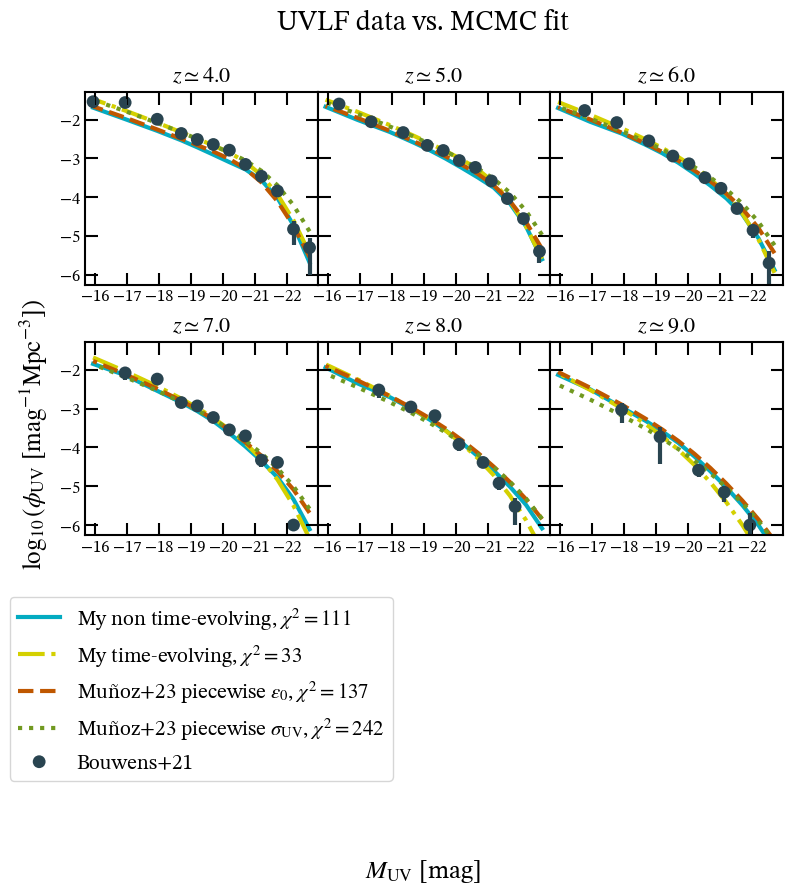

In [ ]:
# UVLF plot
ev_fig = eplots.evolving_UVLF_fit(new_UVLF, plot_from_chain = False, comparison_fits = [best_fit_old, best_fit_new, munoz_fit_1, munoz_fit_2],
                                  comparison_labels = ['My non time-evolving', 'My time-evolving', r'Muñoz+23 piecewise $\epsilon_0$', r'Muñoz+23 piecewise $\sigma_{\rm{UV}}$'])
#ev_fig.savefig(f'{folder}/evolving_UVLF_fit_comparison.png', bbox_inches = 'tight')